In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, TargetEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [105]:
df = pd.read_csv("../data/data_cleaned-v7.csv")

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28152 entries, 0 to 28151
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Price                        28152 non-null  float64
 1   new_car_price                28152 non-null  float64
 2   overview_Fuel type           28152 non-null  object 
 3   Manufacturing Year           28152 non-null  int64  
 4   Brand                        28152 non-null  object 
 5   Model                        28152 non-null  object 
 6   Varient                      28152 non-null  object 
 7   Kilometer                    28152 non-null  float64
 8   ownership                    28152 non-null  object 
 9   Transmission                 28152 non-null  object 
 10  Insurance                    28152 non-null  int64  
 11  Registration_Type            28152 non-null  object 
 12  City                         28152 non-null  object 
 13  Engine(cc)      

In [107]:
df.select_dtypes("object").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28152 entries, 0 to 28151
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   overview_Fuel type  28152 non-null  object
 1   Brand               28152 non-null  object
 2   Model               28152 non-null  object
 3   Varient             28152 non-null  object
 4   ownership           28152 non-null  object
 5   Transmission        28152 non-null  object
 6   Registration_Type   28152 non-null  object
 7   City                28152 non-null  object
 8   Emission_Standard   28152 non-null  object
dtypes: object(9)
memory usage: 1.9+ MB


In [108]:
df.columns.values

array(['Price', 'new_car_price', 'overview_Fuel type',
       'Manufacturing Year', 'Brand', 'Model', 'Varient', 'Kilometer',
       'ownership', 'Transmission', 'Insurance', 'Registration_Type',
       'City', 'Engine(cc)', 'Max_Power(bhp)', 'Mileage',
       'Emission_Standard', 'Seating_Capacity', 'Fuel_Tank_Capcity',
       'Safety_Score', 'Sunroof', 'Praking_Sensors', 'Keyless_Start',
       'GPS_Navigation', 'ADAS', 'Automatic_Emergency_Braking',
       'Driving_Range', 'Regenerative_Braking', 'CNG_Capacity',
       'Supercharger', 'Four_Wheel_Drive'], dtype=object)

In [109]:
df["overview_Fuel type"].value_counts()
#  Petrol  Deiseal   CNG
#   1        0        0
#   0        1        0

overview_Fuel type
Petrol           16381
Diesel            9813
CNG               1009
Electric           847
LPG                 92
Not Available       10
Name: count, dtype: int64

## Encoding Techniques
- Label Encoder
- OneHot Encoding

In [110]:
df["overview_Fuel type"] = df["overview_Fuel type"].replace({"Not Available":"Petrol"})

In [111]:
ohe_cols = [
    "overview_Fuel type",
    "Brand",
    "City",
]
ordinal_cols = [
    "Emission_Standard",
    "ownership",
    "Transmission",
    "Registration_Type",
]

target_cols = ["Model"]


In [112]:
df.drop(columns=["Varient"],inplace=True)

In [113]:
for col in df.select_dtypes("object").columns:
    print(col)
    print(f"Unique Values Count: ",df[col].nunique())
    print(f"Values: \n{df[col].value_counts()}")
    print("="*100)

overview_Fuel type
Unique Values Count:  5
Values: 
overview_Fuel type
Petrol      16391
Diesel       9813
CNG          1009
Electric      847
LPG            92
Name: count, dtype: int64
Brand
Unique Values Count:  22
Values: 
Brand
Maruti           4903
Hyundai          4416
Tata             2407
Mahindra         2216
Honda            1892
Toyota           1871
Mercedes-Benz    1560
Kia              1538
BMW               948
Renault           877
Ford              857
MG                833
Volkswagen        813
Skoda             778
Audi              601
Land              393
Jeep              384
Nissan            337
Volvo             199
Jaguar            167
Chevrolet         124
Fiat               38
Name: count, dtype: int64
Model
Unique Values Count:  275
Values: 
Model
Suzuki     4903
Creta       999
City        816
Seltos      788
Innova      719
           ... 
G580          1
Patrol        1
Teana         1
Prius         1
Marshal       1
Name: count, Length: 275, dtype: i

In [114]:
abs(df.select_dtypes(exclude="object").corr()["Price"]).sort_values(ascending=False)

Price                          1.000000
new_car_price                  0.828158
Max_Power(bhp)                 0.758263
Engine(cc)                     0.591886
Fuel_Tank_Capcity              0.574351
Safety_Score                   0.519124
Four_Wheel_Drive               0.518486
Sunroof                        0.398517
Automatic_Emergency_Braking    0.397899
Mileage                        0.397759
Manufacturing Year             0.328586
GPS_Navigation                 0.327220
Keyless_Start                  0.326064
Supercharger                   0.303682
Praking_Sensors                0.214665
ADAS                           0.198641
Driving_Range                  0.135854
Regenerative_Braking           0.124993
Insurance                      0.115107
Seating_Capacity               0.109829
Kilometer                      0.082659
CNG_Capacity                   0.021506
Name: Price, dtype: float64

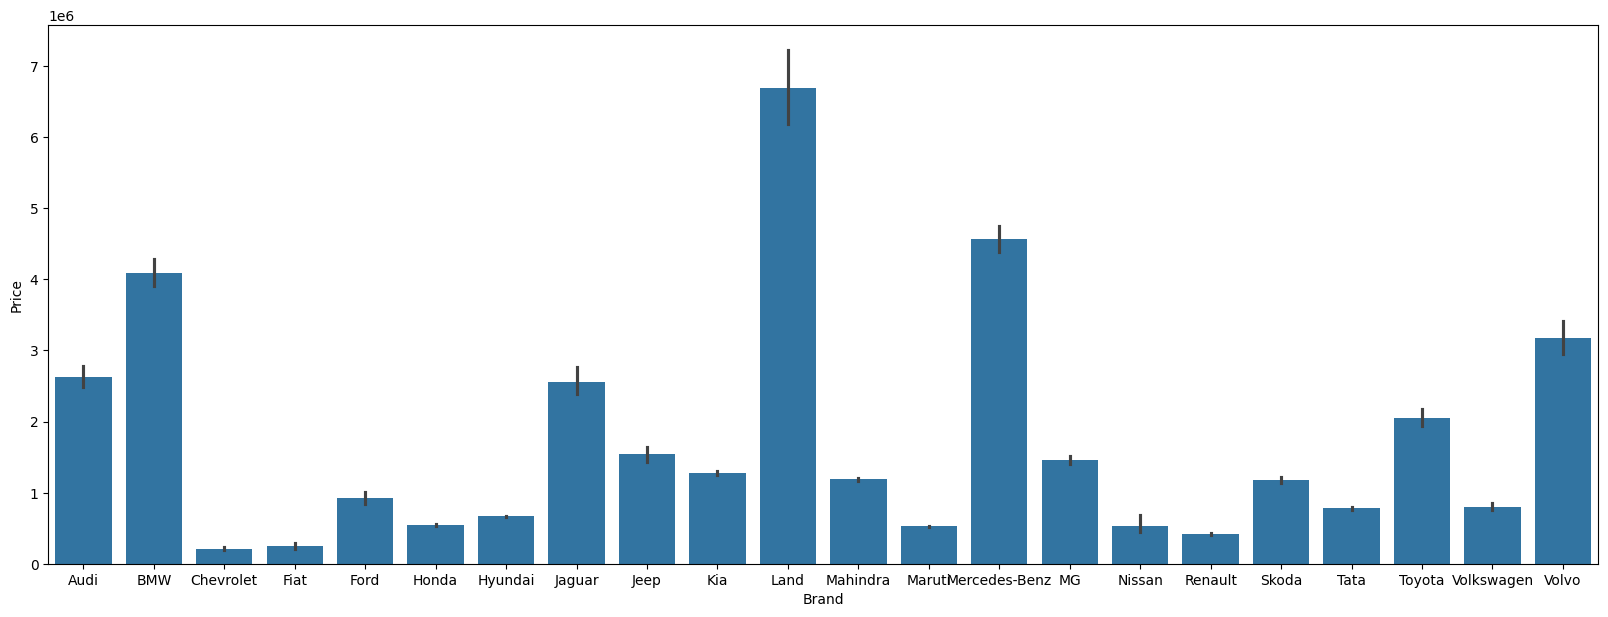

In [115]:
plt.figure(figsize=(20,7))
sns.barplot(df,x="Brand",y="Price")
plt.show()

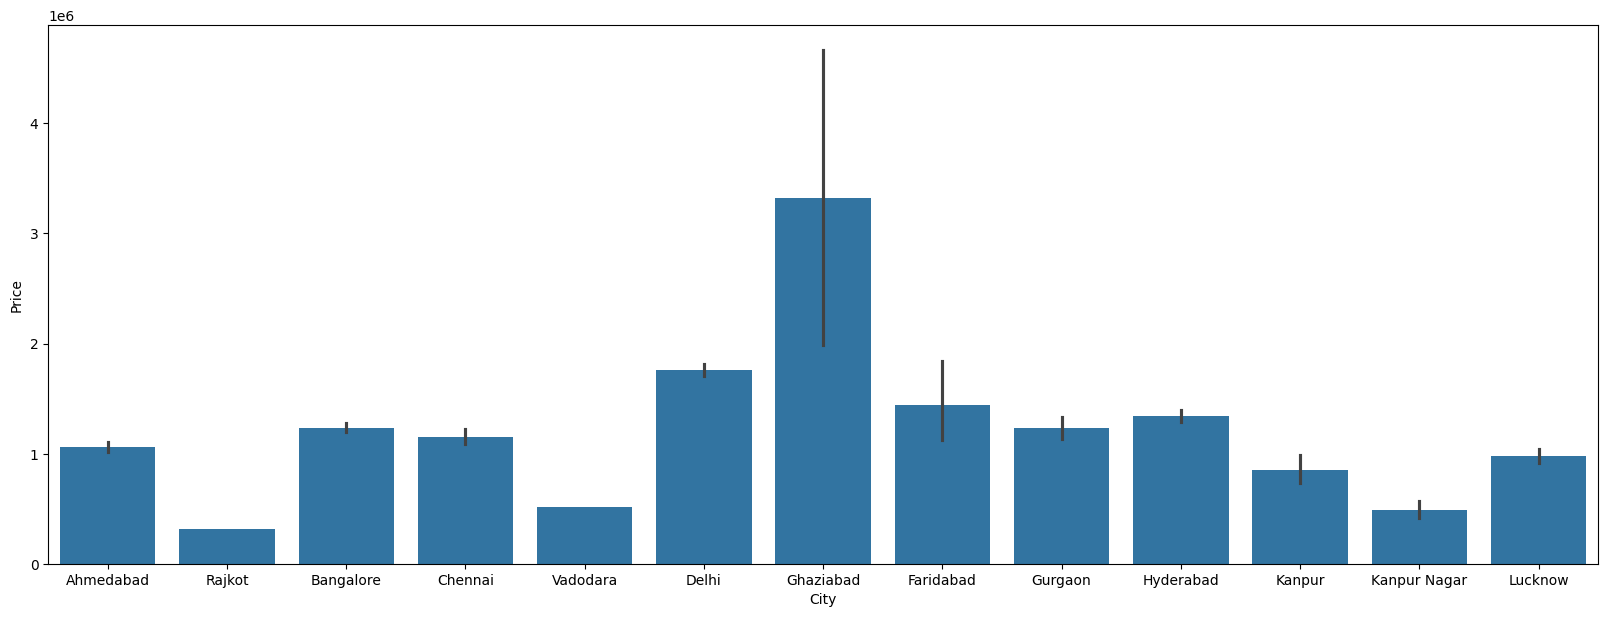

In [116]:
plt.figure(figsize=(20,7))
sns.barplot(df,x="City",y="Price")
plt.show()

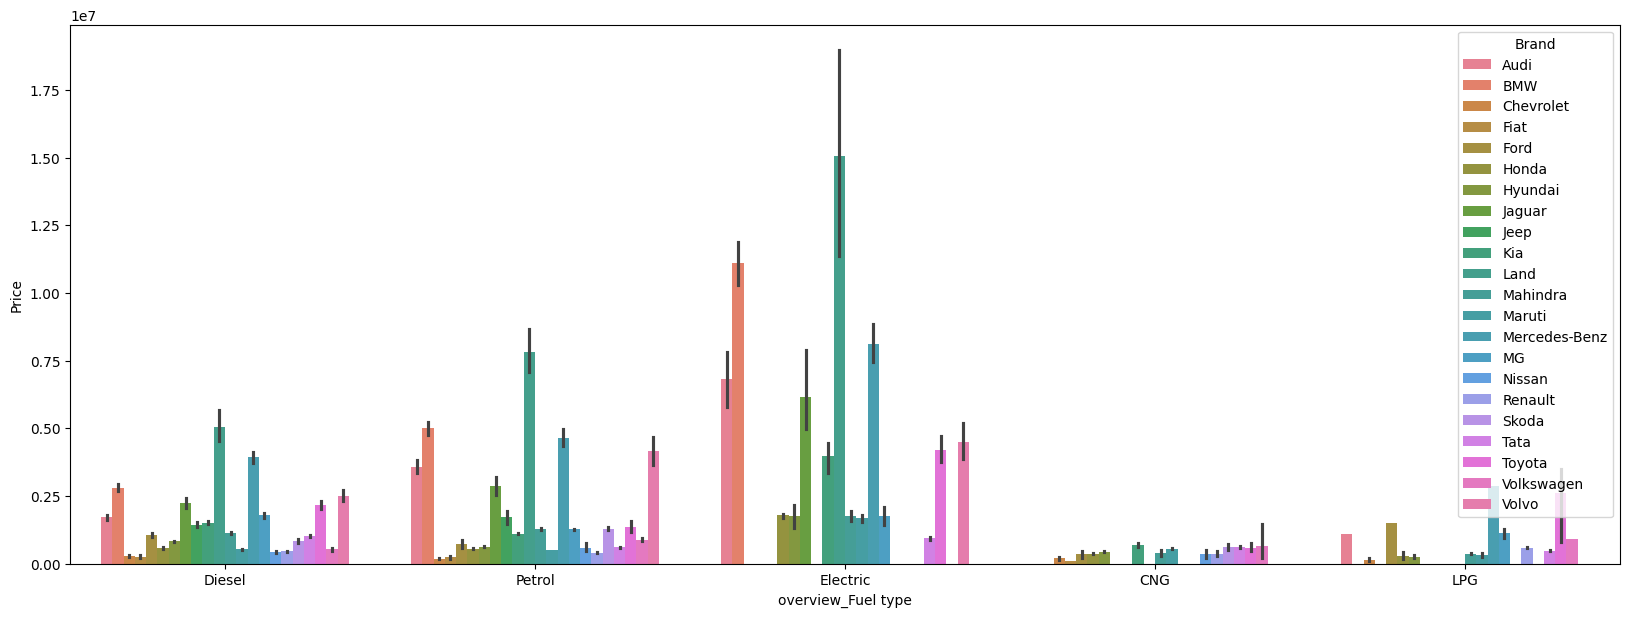

In [117]:
plt.figure(figsize=(20,7))
sns.barplot(df,x="overview_Fuel type",y="Price",hue="Brand")
plt.show()

In [118]:
X = df.drop(columns = "Price")
Y = df["Price"]

In [119]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=25
)

In [120]:
print("Training Sample: ", x_train.shape[0])
print("Testing Sample: ", x_test.shape[0])

Training Sample:  22521
Testing Sample:  5631


In [121]:
num_cols = X.select_dtypes(exclude="object").columns.values

In [122]:
preprocessing = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ohe_cols),
        ("ordinal",OrdinalEncoder(),ordinal_cols),
        ("target", TargetEncoder(), target_cols),
        ("numeric", "passthrough", num_cols),
    ]
)

In [123]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [124]:
preprocessing.fit_transform(X,Y)

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 1.],
       [0., 1., 0., ..., 0., 1., 1.]], shape=(28152, 66))

In [155]:
pipleline = Pipeline(steps=[
    ("preprocessing",preprocessing),
    ("model",GradientBoostingRegressor(random_state=25,max_depth=5))
])

In [156]:
pipleline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [160]:
y_test_pred = pipleline.predict(x_test)
y_train_pred = pipleline.predict(x_train)

In [161]:
print("R2 Score: ",r2_score(y_train,y_train_pred))
print("MSE: ",mean_absolute_error(y_train,y_train_pred))

R2 Score:  0.9811081613420845
MSE:  141628.18236984618


In [ ]:
print("R2 Score: ",r2_score(y_test,y_test_pred))
print("MSE: ",mean_absolute_error(y_test,y_test_pred)) # 94% --> 98%

R2 Score:  0.9355895299861277
MSE:  169432.07087048262


In [163]:
pred_price = pipleline.predict(x_train.iloc[[10]])
print("Actual: ",y_train.iloc[10])
print("Prediction: ",pred_price)

Actual:  1495000.0
Prediction:  [1370061.75719397]


In [159]:
pred_price = pipleline.predict(x_test.iloc[[8]])
print("Actual: ",y_test.iloc[8])
print("Prediction: ",pred_price)

Actual:  14900000.0
Prediction:  [17588177.1042729]
